In [ ]:
import pandas as pd
import matplotlib.pyplot as plt 

In [2]:
df = pd.read_csv("../data/ai4i2020.csv")
df.tail(10)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
9990,9991,L57170,L,298.8,308.5,1527,36.2,3,0,0,0,0,0,0
9991,9992,M24851,M,298.9,308.4,1827,26.1,5,0,0,0,0,0,0
9992,9993,L57172,L,298.8,308.4,1484,39.2,8,0,0,0,0,0,0
9993,9994,L57173,L,298.8,308.4,1401,47.3,10,0,0,0,0,0,0
9994,9995,L57174,L,298.8,308.3,1634,27.9,12,0,0,0,0,0,0
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0
9999,10000,M24859,M,299.0,308.7,1500,40.2,30,0,0,0,0,0,0


In [3]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [5]:
df = df.drop(columns=["Product ID","TWF","HDF","PWF","OSF","RNF"])
df.rename(columns={"Air temperature [K]":"Air_temperature","Process temperature [K]":"Process_temperature",
                  "Rotational speed [rpm]":"Rotational_speed","Torque [Nm]":"Torque","Tool wear [min]":"Tool_wear"},inplace=True)
df.head()
types = pd.get_dummies(df['Type'],drop_first=True)
df.drop('Type',axis='columns',inplace=True)
types.head()

,L,M
0,False,True
1,True,False
2,True,False
3,True,False
4,True,False


In [6]:
df = pd.concat([df,types],axis='columns')

In [7]:
from sklearn.model_selection import train_test_split as tts
from sklearn.metrics import ConfusionMatrixDisplay as cmd
from sklearn.metrics import accuracy_score

x = df.drop('Machine failure',axis='columns')
y = df['Machine failure']
xtrain,xtest,ytrain,ytest = tts(x,y,stratify=y,test_size=0.2,random_state=42)

Accuract Score for Random forest =  0.981
Number of trees used :  100


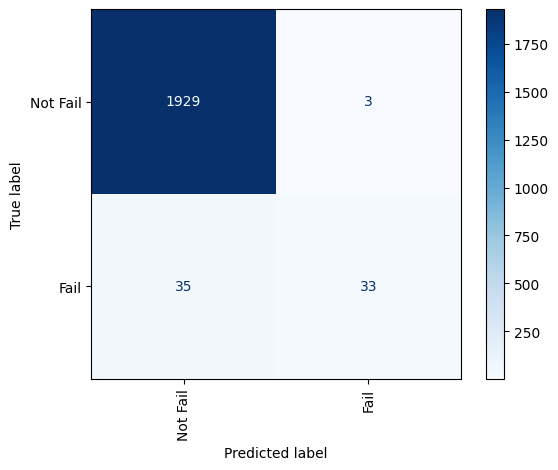

In [8]:
from sklearn.ensemble import RandomForestClassifier

model1 = RandomForestClassifier(class_weight='balanced')
model1.fit(xtrain,ytrain)
ypred = model1.predict(xtest)
print("Accuract Score for Random forest = ",accuracy_score(ytest,ypred))
print("Number of trees used : ",model1.n_estimators)
cmd.from_estimator(model1,xtest,ytest,display_labels=['Not Fail','Fail'],cmap='Blues',xticks_rotation='vertical')
plt.show()

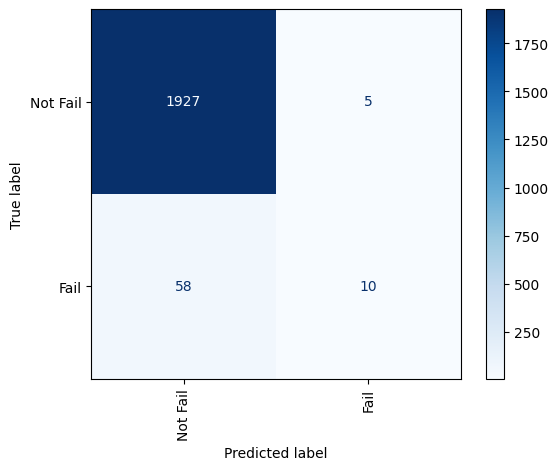

In [9]:
from sklearn.linear_model import LogisticRegression

model2=LogisticRegression(max_iter=1000)
model2.fit(xtrain,ytrain)
cmd.from_estimator(model2,xtest,ytest,display_labels=['Not Fail','Fail'],cmap='Blues',xticks_rotation='vertical')
plt.show()

Gradient Boosting Classifier accuracy score =  0.988


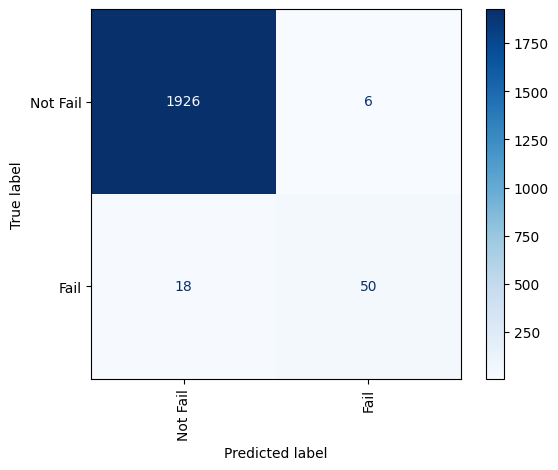

In [10]:
from sklearn.ensemble import GradientBoostingClassifier as GBC

model3 = GBC(max_depth=10,n_estimators=200)
model3.fit(xtrain,ytrain)
ypred = model3.predict(xtest)
print("Gradient Boosting Classifier accuracy score = ",accuracy_score(ytest,ypred))
cmd.from_estimator(model3,xtest,ytest,display_labels=['Not Fail','Fail'],cmap='Blues',xticks_rotation='vertical')
plt.show()

Accuracy score by using XGB classifier =  0.987


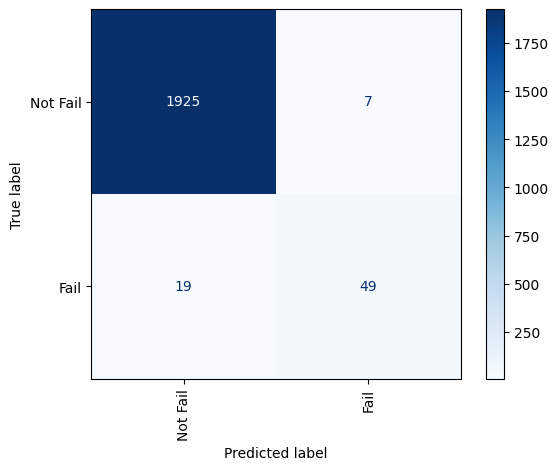

In [13]:
from xgboost import XGBClassifier

model4 = XGBClassifier()
model4.fit(xtrain,ytrain)
ypred = model4.predict(xtest)
print("Accuracy score by using XGB classifier = ",accuracy_score(ytest,ypred))
cmd.from_estimator(model4,xtest,ytest,display_labels=['Not Fail','Fail'],cmap='Blues',xticks_rotation='vertical')
plt.show()